# Importing Libraries

In [12]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


from sklearn.decomposition import PCA


import joblib

import warnings
warnings.filterwarnings("ignore")

# Load Artifacts

In [13]:
X_train = joblib.load(
    ARTIFACT_DIR / "X_train_scaled.pkl"
)

X_test = joblib.load(
    ARTIFACT_DIR / "X_test_scaled.pkl"
)

y_train = joblib.load(
    ARTIFACT_DIR / "y_train.pkl"
)

y_test = joblib.load(
    ARTIFACT_DIR / "y_test.pkl"
)

selected_features = joblib.load(
    ARTIFACT_DIR / "selected_features.pkl"
)

top_consensus_genes = joblib.load(
    ARTIFACT_DIR / "top_consensus_genes.pkl"
)

label_encoder = joblib.load(
    ARTIFACT_DIR / "label_encoder.pkl"
)

# Creating Consensus Feature Space

## Converting Gene Names → Indices

In [16]:
feature_index_map = {
    gene: idx
    for idx, gene in enumerate(selected_features)
}

consensus_indices = [
    feature_index_map[g]
    for g in top_consensus_genes
    if g in feature_index_map
]

## Filter Features

In [5]:
X_train_consensus = X_train[:, consensus_indices]

X_test_consensus = X_test[:, consensus_indices]

print(X_train_consensus.shape)

(104, 231)


# Creating PCA Representation

In [17]:
pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

In [18]:
print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: 0.7974375


# Defining Feature Spaces

In [19]:
feature_spaces = {
    "full": (X_train, X_test),
    "consensus": (
        X_train_consensus,
        X_test_consensus
    ),
    "pca": (
        X_train_pca,
        X_test_pca
    )
}

# Defining Models

In [20]:
models = {

    "logistic_regression":
        LogisticRegression(
            max_iter=5000,
            n_jobs=-1
        ),

    "svm":
        SVC(
            kernel="rbf",
            probability=True
        ),

    "random_forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "xgboost":
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        ),

    "lightgbm":
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=42
        )
}

## Benchmark Loop

### Results Storage

In [10]:
results = []
trained_models = {}

### Training Loop

In [22]:
for feature_name, (
    Xtr,
    Xte
) in feature_spaces.items():

    print(f"\nFeature Space: {feature_name}")

    for model_name, model in models.items():

        print(f"Training: {model_name}")

        # Train
        model.fit(Xtr, y_train)

        # Predict
        preds = model.predict(Xte)

        # Metrics
        accuracy = accuracy_score(
            y_test,
            preds
        )

        f1 = f1_score(
            y_test,
            preds,
            average="weighted"
        )

        # Store results
        results.append({
            "feature_space": feature_name,
            "model": model_name,
            "accuracy": accuracy,
            "f1_score": f1
        })

        # Save trained model
        trained_models[
            f"{feature_name}_{model_name}"
        ] = model


Feature Space: full
Training: logistic_regression
Training: svm
Training: random_forest
Training: xgboost
Training: lightgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.280697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1216831
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 33519
[LightGBM] [Info] Start training from score -1.466337
[LightGBM] [Info] Start training from score -1.147883
[LightGBM] [Info] Start training from score -1.508897
[LightGBM] [Info] Start training from score -1.466337
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

### Results Table

In [21]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="f1_score",
    ascending=False
)

,feature_space,model,accuracy,f1_score
4,full,lightgbm,1.000000,1.000000
5,consensus,logistic_regression,1.000000,1.000000
6,consensus,svm,1.000000,1.000000
9,consensus,lightgbm,1.000000,1.000000
0,full,logistic_regression,0.961538,0.961736
1,full,svm,0.961538,0.961736
2,full,random_forest,0.961538,0.961736
7,consensus,random_forest,0.961538,0.961736
10,pca,logistic_regression,0.961538,0.961736
11,pca,svm,0.961538,0.961736


## Visualization

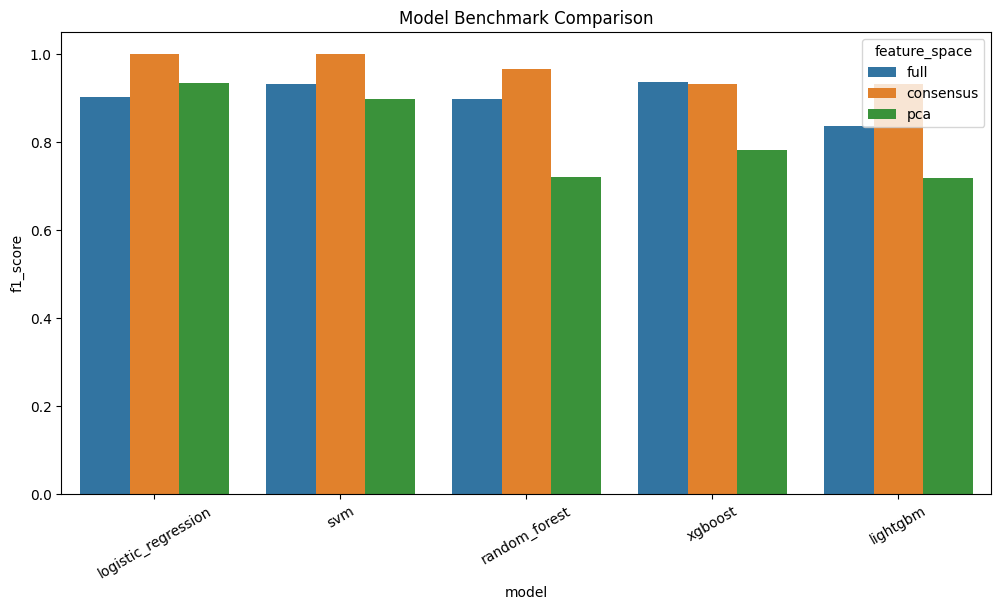

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="model",
    y="f1_score",
    hue="feature_space"
)

plt.title("Model Benchmark Comparison")

plt.xticks(rotation=30)

plt.show()